# Description

This notebook cotains a model to predict the daily average load for the next 5 weeks in a single step. The features are detailed in days.

# Load Libs

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

import pendulum

In [2]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [3]:
regiao = 'SUDESTE'
SEED = 42

batch_size = 32
# number of week to be predicted
predict_weeks = 5
# target days to sum into weeks
target_period = 7*predict_weeks
# number of weeks in the window
n_weeks_ws = 5
# window size in days for each row
window_size = 7*n_weeks_ws

filepath = 'Models/Model_v2.h5'


np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load data

In [4]:
def load_data(start=2009, end=2021):
    """load data from ONS"""

    cwd_dir = os.getcwd()
     
    first_year = os.path.join(cwd_dir, f'Data/CARGA_ENERGIA_{start}.csv')

    df_20XX = pd.read_csv(first_year, 
                        sep=';', 
                        parse_dates=['din_instante'])

    for x in range(start+1,end+1):
        df_20XX = pd.concat(objs = (df_20XX,
                                    pd.read_csv(os.path.join(cwd_dir, 
                                                            f'Data/CARGA_ENERGIA_{x}.csv'), 
                            sep=';', 
                            parse_dates=['din_instante'])))
    return df_20XX.reset_index(drop=True)

In [5]:
df_20XX = load_data(start=2009, end=2021)
df_20XX.tail()

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
18988,SE,SUDESTE,2021-12-30,38850.805500
18989,N,NORTE,2021-12-31,5396.575583
18990,NE,NORDESTE,2021-12-31,10835.873958
18991,S,SUL,2021-12-31,10689.669167
18992,SE,SUDESTE,2021-12-31,35249.151750


# Preprocess data

In [6]:
class Preprocessor(BaseEstimator, TransformerMixin):

  def __init__(self, regiao):
    self.regiao = regiao
    self.missing_days = []
    pass


  def fit(self, df:pd.DataFrame,):
    """ Learns the missing days """
    df = df.copy()
    # filter by subsystem
    df = self.filter_subsystem(df, regiao = self.regiao)
    # saves missing days in a variable called missing_days 
    self.missing_days = df[pd.isna(df.val_cargaenergiamwmed)].din_instante
    return self 


  def transform(self, df:pd.DataFrame):
    """ Applies transformations """
    df = df.copy()
    df = self.filter_subsystem(df, regiao = self.regiao)  # filter by subsystem
    df = self.impute_nan(df)                              # impute/drop NaN values
    df = self.go_to_friday(df)        # starts the dataset at a friday - the operative week 
    df = self.parse_dates(df)         # create columns parsing the data
    df = self.drop_incomplete_week(df)    # drop last rows so to have full weeks
    self.check_dq(df)                   # prints the NaN values for loadand missing days
    return df


  def filter_subsystem(self, df:pd.DataFrame, regiao:str):
    """ filter data by subsystem and reset index """
    df = df.copy()
    # try and execept so it doesn't crash if it's applied to an already treated dataset
    try:
      df = df[df['nom_subsistema']==regiao].reset_index().drop('index',axis=1).copy()
    except:
      pass
    # dropa columns about subsystem
    df.drop(labels=['nom_subsistema','id_subsistema'], inplace=True, axis=1,errors='ignore')
    # reset index of concatenated datasets
    df.reset_index(inplace=True,drop=True)
    return df


  def impute_nan(self, df):
    """ impute the 12 NaN values """
    df = df.copy()
    time_col = 'din_instante'
    load_col = 'val_cargaenergiamwmed'
    if len(self.missing_days) != 0:
      # If the NaN weren't already dealt with:
      if df[df[time_col] == self.missing_days.iloc[0]].val_cargaenergiamwmed.isna().item():
        # impute missing day '2013-12-01' with the load from the day before
        df.at[(df[df.din_instante == self.missing_days.iloc[0]].index.item()), 
              load_col] = df[load_col].iloc[self.missing_days.index[0] - 1]
        # impute missing day '2014-02-01' with the load from the day before
        df.at[(df[df.din_instante == self.missing_days.iloc[1]].index.item()), 
              load_col] = df[load_col].iloc[self.missing_days.index[1] - 1]
        
        # Impute 2015-04-09
        # variation between april 9 (wednesday) and april 10 (thursday) of 2014
        var2014 = df[df['din_instante'] == r'2014-04-10'].val_cargaenergiamwmed.item() /  df[df['din_instante'] == r'2014-04-09'].val_cargaenergiamwmed.item()
        # index of 2015-04-09, the missing day in 2015
        index_2015 = df[df['din_instante'] == r'2015-04-09'].index.item()
        # replace the missing day of 2015 with the day before * variation between same days in 2014
        df.loc[index_2015, 'val_cargaenergiamwmed'] = df[df['din_instante'] == r'2015-04-08'].val_cargaenergiamwmed.item()*var2014

        # Impute missing days from 2016-04-05 to 2016-04-13
        # list of daily variations between 2015-04-07 and 2015-04-16  
        var_2015 =[]
        for dia in range(7,16):
            var_2015.append(df[df['din_instante'] == r'2015-04-{:0>2d}'.format(dia)].val_cargaenergiamwmed.item() / 
                        df[df['din_instante'] == r'2015-04-{:0>2d}'.format(dia-1)].val_cargaenergiamwmed.item())
        # index of 2016-04-05, the begining of the 9 missing days in 2016
        index_2016 = df[df['din_instante'] == r'2016-04-05'].index.item()

        for x in range(0,9):
            df.loc[index_2016 + x,'val_cargaenergiamwmed'] = df[df['din_instante'] == r'2015-04-{:0>2d}'.format(x+7)].val_cargaenergiamwmed.item()*var_2015[x]
    return df


  def go_to_friday(self,df): 
    """ go next friday = begining of the operative week"""
    df = df.copy()
    # first day in dataset
    date_time = df['din_instante'].iloc[0]
    # check if the dataset starts on a friday 
    if date_time.day_name() != 'Friday':
      # today
      dt = pendulum.datetime(date_time.year,date_time.month, date_time.day)
      # next friday - begins the operative week
      next_friday = dt.next(pendulum.FRIDAY).strftime('%Y-%m-%d')
      # df starts with the begin of operative week
      df = df[df['din_instante'] >= next_friday].reset_index(drop=True).copy()
    
    return df


  def parse_dates(self, df):
    """ parse date into year, month, month day and week day  """
    df = df.copy()
    
    df['semana'] = (df.index)//7
    df['dia semana'] = df['din_instante'].dt.day_name()
    df['dia mes'] = df['din_instante'].dt.day
    df['Mes'] = df['din_instante'].dt.month
    df['ano'] = df['din_instante'].dt.year
    return df


  def drop_incomplete_week(self,df):
    """ drop incomplete week at the bottom of the dataset """
    for i in range(6):
      if df['dia semana'].tail(1).item() == 'Thursday':
        break
      else:
        df.drop(labels=df.tail(1).index, axis=0, inplace=True)

    return df
  

  def check_dq(self,df):
    # check for NaN values
    nan_data = df[pd.isna(df.val_cargaenergiamwmed)].din_instante
    if len(nan_data) != 0:
        print("NaN values: \n")
        print(nan_data)
    else:
        print('No missing NaN.')
    
    # check for missing days in the series
    missing_days = pd.date_range(start = df.din_instante.iloc[0], 
                                 end= df.din_instante.iloc[-1],
                                 freq='D').difference(df.din_instante)
    if len(missing_days) != 0:
        print("\nMissing days in the series:")
        print(missing_days)
    else:
        print("\nNo missing days in the series")

  def split_time(self, df, val_start=0.7, test_start=0.9):
    """ Split dataset into train, validation and teste data

    Args:
        df (pd.DataFrame): data
        val_start (float, optional): the proportion of the dataset where starts validation data. Defaults to 0.7.
        test_start (float, optional): the proportion of the dataset where starts test data. Defaults to 0.9.
        regiao (str, optional): Subsystem to filter data. Defaults to "SUDESTE".

    Returns:
        pd.DataFrame: train data, validation data and test data dataframes 
    """
    df = df.copy()
    # index of end of training dataset, start of validation dataset
    split_val = int(len(df)*val_start)
    # make sure we split the dataset on a friday - first day of the operative week
    for x in range(0,7):
        # Check if the last day is friday, then the day before, then before...
        if df.loc[split_val-x,'dia semana'] == 'Friday':
            # when we find the friday before the split, we update the split index
            split_val = split_val - x
            break
    # index of end of validation dataset, start of test dataset
    split_test = int(len(df)*test_start)
    # make sure we split the dataset on a friday - first day of the operative week
    for i in range(0,7):
      # Check if the last day is friday, then the day before, then before...
        if df.loc[split_test-i,'dia semana'] == 'Friday':
            # when we find the friday before the split, we update the split index
            split_test = split_test - i
            break    
    # split datasets
    train_df = df[:split_val]
    val_df = df[split_val:split_test]
    test_df = df[split_test:]

    print(f"First day of train_df: {train_df.din_instante.iloc[0]}")
    print(f"First day of val_df: {val_df.din_instante.iloc[0]}")
    print(f"First day of test_df: {test_df.din_instante.iloc[0]}")
    return train_df, val_df, test_df


In [7]:
pp = Preprocessor(regiao='SUDESTE')
df = pp.fit_transform(df_20XX)

No missing NaN.

No missing days in the series


# Split Data

In [8]:
train_df, val_df, test_df = pp.split_time(df=df,
                                            val_start=0.7, 
                                            test_start=0.9)

First day of train_df: 2009-01-02 00:00:00
First day of val_df: 2018-02-02 00:00:00
First day of test_df: 2020-09-11 00:00:00


# Process Data 

In [9]:
class Window_Generator(BaseEstimator):
    
    def __init__(self,target_period, window_size, batch_size,
                 shuffle_buffer, regiao = regiao, SEED=SEED):
        self.target_period = target_period
        self.window_size = window_size
        self.batch_size = batch_size
        self.shuffle_buffer = shuffle_buffer
        self.regiao = regiao
        self.SEED = SEED
    pass
    
    def generate_data_week(self, df):
        """Generate a list with the same index as the window features with the first
            day of the first week of the target
        Returns:
            data_week: first day of the first target week
        """
        df = df.copy()
        # if df['din_instante'].iloc[0].day_name() != 'Friday':
        #     # get next friday - begins the operative week
        #     df = Preprocessor(regiao=self.regiao).go_to_friday(df)
        # groupby object by week and then by day
        df_grouped = df[self.window_size:].groupby(by=['semana'])['din_instante']
        # get first day of each week and  removes the last 4 rows 
        # because we want to save the first day of the first target week
        # so we drop the last target 4 weeks 
        return df_grouped.min()[:-4]

    def transform(self, df, shuffle=True):
        """Transform a preprocessed dataframe in a windowed dataset
        Returns:
            dataset: a windowed tensorflow.dataset with window_size timesteps for features
                     and the average daily load for the next five weeks as targets
        """
        df = df.copy()
        data_week = self.generate_data_week(df)

        series = df['val_cargaenergiamwmed']
        # generate tf.dataset
        dataset = tf.data.Dataset.from_tensor_slices(series)
        
        # create windows 
        dataset = dataset.window(self.window_size + self.target_period, shift=7, drop_remainder=True)
        # make sure every window is the same size / clip NaN at the end
        dataset = dataset.flat_map(lambda window: window.batch(self.window_size + self.target_period))
        if shuffle:
            # randomly shuffles the windows instances in the dataset 
            dataset = dataset.shuffle(self.shuffle_buffer,seed=self.SEED)
        # separates features and target and average the target days
        dataset = dataset.map(lambda window:(window[:-self.target_period],   #features
                                            [tf.math.reduce_sum(window[-35:-28])/7, # first target week
                                            tf.math.reduce_sum(window[-28:-21])/7, # second target week
                                            tf.math.reduce_sum(window[-21:-14])/7, # third target week
                                            tf.math.reduce_sum(window[-14:-7])/7,  # fourth target week
                                            tf.math.reduce_sum(window[-7:])/7]      # fifith target week
                                            )
                            )
        # batch and prefetch
        dataset = dataset.batch(batch_size).prefetch(1)
        return dataset, data_week


wd = Window_Generator(batch_size = batch_size, 
                     window_size = window_size,
                     shuffle_buffer = 20, 
                     target_period = target_period, 
                     SEED = SEED)



# dataset to training
train_dataset, train_data_week = wd.transform(df = train_df, shuffle=True)

# dataset for performance evaluation
train_pred_dataset, train_pred_data_week = wd.transform(df = train_df, shuffle=False)
val_dataset, val_data_week = wd.transform(df = val_df, shuffle=False)
test_dataset, test_data_week = wd.transform(df = test_df, shuffle=False)

In [10]:
c=0
for x,y in train_pred_dataset:
  #print('x=', x)
  #print('y=', y)
  #break
  c +=1
print(c*batch_size)

480


# Target

In [11]:
def create_target_df(df):
  """ returns a dataframe with target values and baseline"""
  # average daily load by operative week
  df_target = pd.DataFrame(data=df.groupby(by=['semana'])['val_cargaenergiamwmed'].mean())
  # start day of each operative week
  df_target.columns = ['Semana 1']
  df_target['Semana 2'] = df_target['Semana 1'].shift(-1)
  df_target['Semana 3'] = df_target['Semana 1'].shift(-2)
  df_target['Semana 4'] = df_target['Semana 1'].shift(-3)
  df_target['Semana 5'] = df_target['Semana 1'].shift(-4)
  # defines the first day of Semana 1
  df_target['Data'] = df.groupby(by=['semana'])['din_instante'].min()
  df_target['dia semana'] = df.groupby(by=['semana'])['dia semana'].min()
  df_target['Resíduo'] = df_target['Semana 2']  - df_target['Semana 1'] 
  return df_target


df_target = create_target_df(df)
df_target.head(6)

,Semana 1,Semana 2,Semana 3,Semana 4,Semana 5,Data,dia semana,Resíduo
semana,,,,,,,,
0,27536.563810,31029.189762,30444.169583,29957.378095,31392.350119,2009-01-02,Friday,3492.625952
1,31029.189762,30444.169583,29957.378095,31392.350119,32150.677321,2009-01-09,Friday,-585.020179
2,30444.169583,29957.378095,31392.350119,32150.677321,31443.203095,2009-01-16,Friday,-486.791488
3,29957.378095,31392.350119,32150.677321,31443.203095,29987.839524,2009-01-23,Friday,1434.972024
4,31392.350119,32150.677321,31443.203095,29987.839524,33188.868750,2009-01-30,Friday,758.327202
5,32150.677321,31443.203095,29987.839524,33188.868750,33265.600952,2009-02-06,Friday,-707.474226


Text(0.5, 1.0, 'Resíduo entre semanas consecutivas - variação de uma semana para a seguinte')

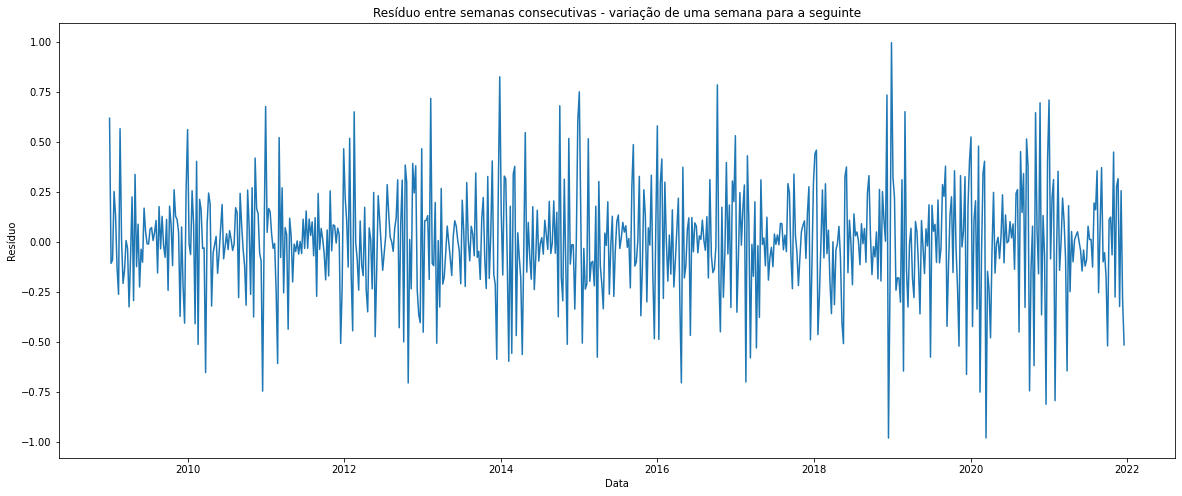

In [12]:
fig, ax =plt.subplots(figsize=(20,8))
# diferença normalizada entre semanas consecutivas
residuo = (df_target['Resíduo'] - df_target['Resíduo'].mean())/df_target['Resíduo'].max()
sns.lineplot(y=residuo, x=df_target['Data'], ax=ax)
ax.set_title("Resíduo entre semanas consecutivas - variação de uma semana para a seguinte")

# Baseline

In [13]:
class Baseline(tf.keras.Model):
  
  """ If how = "last week", pass the last week five times as prediction
      for the next five weeks. 
      IF how = "five weeks" past the last 5 weeks of the input window 
      as predictions for the next five 
  """
  
  def __init__(self,how):
    super().__init__()
    self.how = how
    pass

  
  def call(self, inputs):

    # last five weeks as prediction for the next five, respectivamente
    if self.how == 'five weeks':
      result =[tf.math.reduce_sum(inputs[0,-35:-28])/7, # first target week - five weeks before
              tf.math.reduce_sum(inputs[0,-28:-21])/7, # second target week - five weeks before
              tf.math.reduce_sum(inputs[0,-21:-14])/7, # third target week - five weeks before
              tf.math.reduce_sum(inputs[0,-14:-7])/7,  # fourth target week - five weeks before
              tf.math.reduce_sum(inputs[0,-7:])/7    # fifith target week - five weeks before
              ]     
    
    # last week five times as prediction for the next five weeks  
    elif self.how == 'last week':
      result=[tf.math.reduce_sum(inputs[0,-7:])/7, # first target week - five weeks before
              tf.math.reduce_sum(inputs[0,-7:])/7, # second target week - five weeks before
              tf.math.reduce_sum(inputs[0,-7:])/7, # third target week - five weeks before
              tf.math.reduce_sum(inputs[0,-7:])/7,  # fourth target week - five weeks before
              tf.math.reduce_sum(inputs[0,-7:])/7    # fifith target week - five weeks before
              ]     

    return result

In [14]:
base_model = Baseline(how='five weeks')
# compile
base_model.compile(loss=tf.losses.MeanSquaredError(),
            metrics=[tf.metrics.MeanAbsoluteError(),
                    tf.metrics.MeanAbsolutePercentageError(),
                    tf.keras.metrics.RootMeanSquaredError()
                    ])

train_performance = base_model.evaluate(train_dataset, verbose=1)
val_performance = base_model.evaluate(val_dataset, verbose=0)
test_performance = base_model.evaluate(test_dataset, verbose=0)

semana1_base = pd.DataFrame(data = {'MAE': [train_performance[6],val_performance[6],test_performance[6]], 
                                    'MAPE': [train_performance[7],val_performance[7],test_performance[7]],
                                    'MSE': [train_performance[1],val_performance[1],test_performance[1]],
                                    "RMSE": [train_performance[8],val_performance[8],test_performance[8]]},
                            index=['train', 'val' , 'test']
                            )
print('\n Metricas da baseline para a semana 1')
semana1_base


15/15 [==============================] - 2s 78ms/step - loss: 38934328.0000 - output_1_loss: 6917492.0000 - output_2_loss: 8284041.0000 - output_3_loss: 8920613.0000 - output_4_loss: 6874772.0000 - output_5_loss: 7937412.5000 - output_1_mean_absolute_error: 2077.3967 - output_1_mean_absolute_percentage_error: 5.8009 - output_1_root_mean_squared_error: 2630.1125 - output_2_mean_absolute_error: 2288.4717 - output_2_mean_absolute_percentage_error: 6.4134 - output_2_root_mean_squared_error: 2878.2012 - output_3_mean_absolute_error: 2345.6394 - output_3_mean_absolute_percentage_error: 6.5603 - output_3_root_mean_squared_error: 2986.7395 - output_4_mean_absolute_error: 2084.5432 - output_4_mean_absolute_percentage_error: 5.8589 - output_4_root_mean_squared_error: 2621.9788 - output_5_mean_absolute_error: 2249.7615 - output_5_mean_absolute_percentage_error: 6.3806 - output_5_root_mean_squared_error: 2817.3413

 Metricas da baseline para a semana 1


,MAE,MAPE,MSE,RMSE
train,2077.396729,5.800855,6917492.00,2630.112549
val,2813.654541,7.874809,11427060.00,3380.393555
test,1610.314209,4.090764,3698280.25,1923.091431


In [15]:
semana5_base = pd.DataFrame(data = {'MAE': [train_performance[-3],val_performance[-3],test_performance[-3]], 
                                    'MAPE': [train_performance[-2],val_performance[-2],test_performance[-2]],
                                    'MSE': [train_performance[2],val_performance[2],test_performance[2]],
                                    "RMSE": [train_performance[-1],val_performance[-1],test_performance[-1]]},
                            index=['train', 'val' , 'test'])

print("Métricas da baseline para semana 5")
semana5_base                            

Métricas da baseline para semana 5


,MAE,MAPE,MSE,RMSE
train,2249.761475,6.380595,8284041.0,2817.341309
val,3560.806641,10.083570,12690636.0,4277.265137
test,1689.003418,4.241097,6460086.0,2140.956543


# train model

In [631]:
def compile_and_fit(model, data, val_data, epochs,optimizer,
                    filepath=filepath, patience=4):
  # early stopping callback
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')
  # checkpoint callback
  checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath = filepath, monitor = 'loss', 
                               verbose = 1, save_best_only = True, mode = 'min')
  
  # compile
  model.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=optimizer,
                metrics=[tf.metrics.MeanAbsoluteError(),
                         tf.metrics.MeanAbsolutePercentageError(),
                         tf.keras.metrics.RootMeanSquaredError()])
  # fit data
  history = model.fit(data, epochs=epochs, verbose=0,
                      validation_data= val_data,
                      callbacks=[early_stopping # , checkpoint
                    ])
  return history

In [543]:
# LSTM
model = tf.keras.models.Sequential([
    tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis = -1), input_shape=[None]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LSTM(80, return_sequences=False, activation ='tanh'),
    tf.keras.layers.Dense(5),
    tf.keras.layers.Lambda(lambda x: x * 10000.0)
    ])


history = compile_and_fit(model, epochs = 100, 
                          data=train_dataset, 
                          val_data = val_dataset,
                          optimizer = tf.optimizers.Adam(learning_rate=0.001),
                          patience = 50,
                          filepath = filepath)


#print("Layer weights {}".format(l0.get_weights())) 

# Evaluate

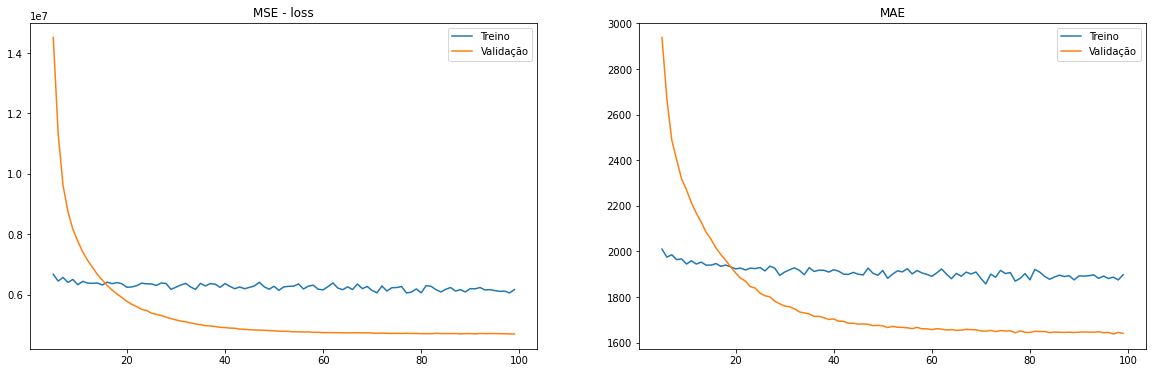

In [544]:
# starting epoch to plot
skip = 5

fig,ax = plt.subplots(figsize=(20,6), nrows=1, ncols=2)
metrics_list = ['loss',
                'val_loss',
                'mean_absolute_error', 
                'val_mean_absolute_error'
                ]

for i, metric in enumerate(metrics_list):
  if i<=1:
    ax1 =  ax.ravel()[0]
  else:
    ax1 =  ax.ravel()[1]
  sns.lineplot(x = range(skip,len(history.history[metric])),
              y = history.history[metric][skip:],
              ax = ax1)


ax.ravel()[0].set_title("MSE - loss")
ax.ravel()[0].legend(labels=['Treino', 'Validação'])
ax.ravel()[1].set_title("MAE")
ax.ravel()[1].legend(labels=['Treino', 'Validação'])

plt.show()

In [728]:
def plot_pred(df_target=df_target, date_list=date_list):
    
    colors = ['orange', 'green', 'purple']
    _,ax=plt.subplots(figsize=(20,30), ncols=1, nrows=4)
    extra = plt.Rectangle((0, 0), 0, 0, fc="none", fill=False, ec='none', linewidth=0)

    
    for x in range(0,4):
        # plot measured data
        sns.lineplot(x = df_target['Data'], 
                    y = df_target[f'Semana {x+1}'], 
                    ax=np.ravel(ax)[x], 
                    color = 'teal')

        # plot predicted data
        for date,pred,color in zip(date_list, 
                                pred_list,
                                colors): 
            
            sns.lineplot(x = date,
                        y = pred[:,x], 
                        ax=np.ravel(ax)[x],
                        color=color)

        np.ravel(ax)[x].set_title(f'Carga real vs Predição em todo o período - Semana {x+1}')
        # np.ravel(ax)[x].legend(['Real','Previsão no treino','Previsão na validação','Previsão no teste'], loc='upper left')

        
        scores = (r"MAE Train ={:.0f}"+'\n'+r"MAE val ={:.0f}"+"\n"+r"MAE test ={:.0f}").format(
                mean_absolute_error(train_pred[:,x], 
                                    df_target['Semana 1'].loc[np.array(date_list[0].index)]),
                mean_absolute_error(val_pred[:,x],
                                    df_target['Semana 1'].loc[np.array(date_list[1].index)]),
                mean_absolute_error(test_pred[:,x], 
                                    df_target['Semana 1'].loc[np.array(date_list[2].index)])
                                                                                                )
        np.ravel(ax)[x].legend([extra], [scores], loc='lower right')
    plt.show()

2/2 [==============================] - 0s 18ms/step - loss: 7132147.0000 - mean_absolute_error: 2135.0688 - mean_absolute_percentage_error: 5.3181 - root_mean_squared_error: 2670.6079


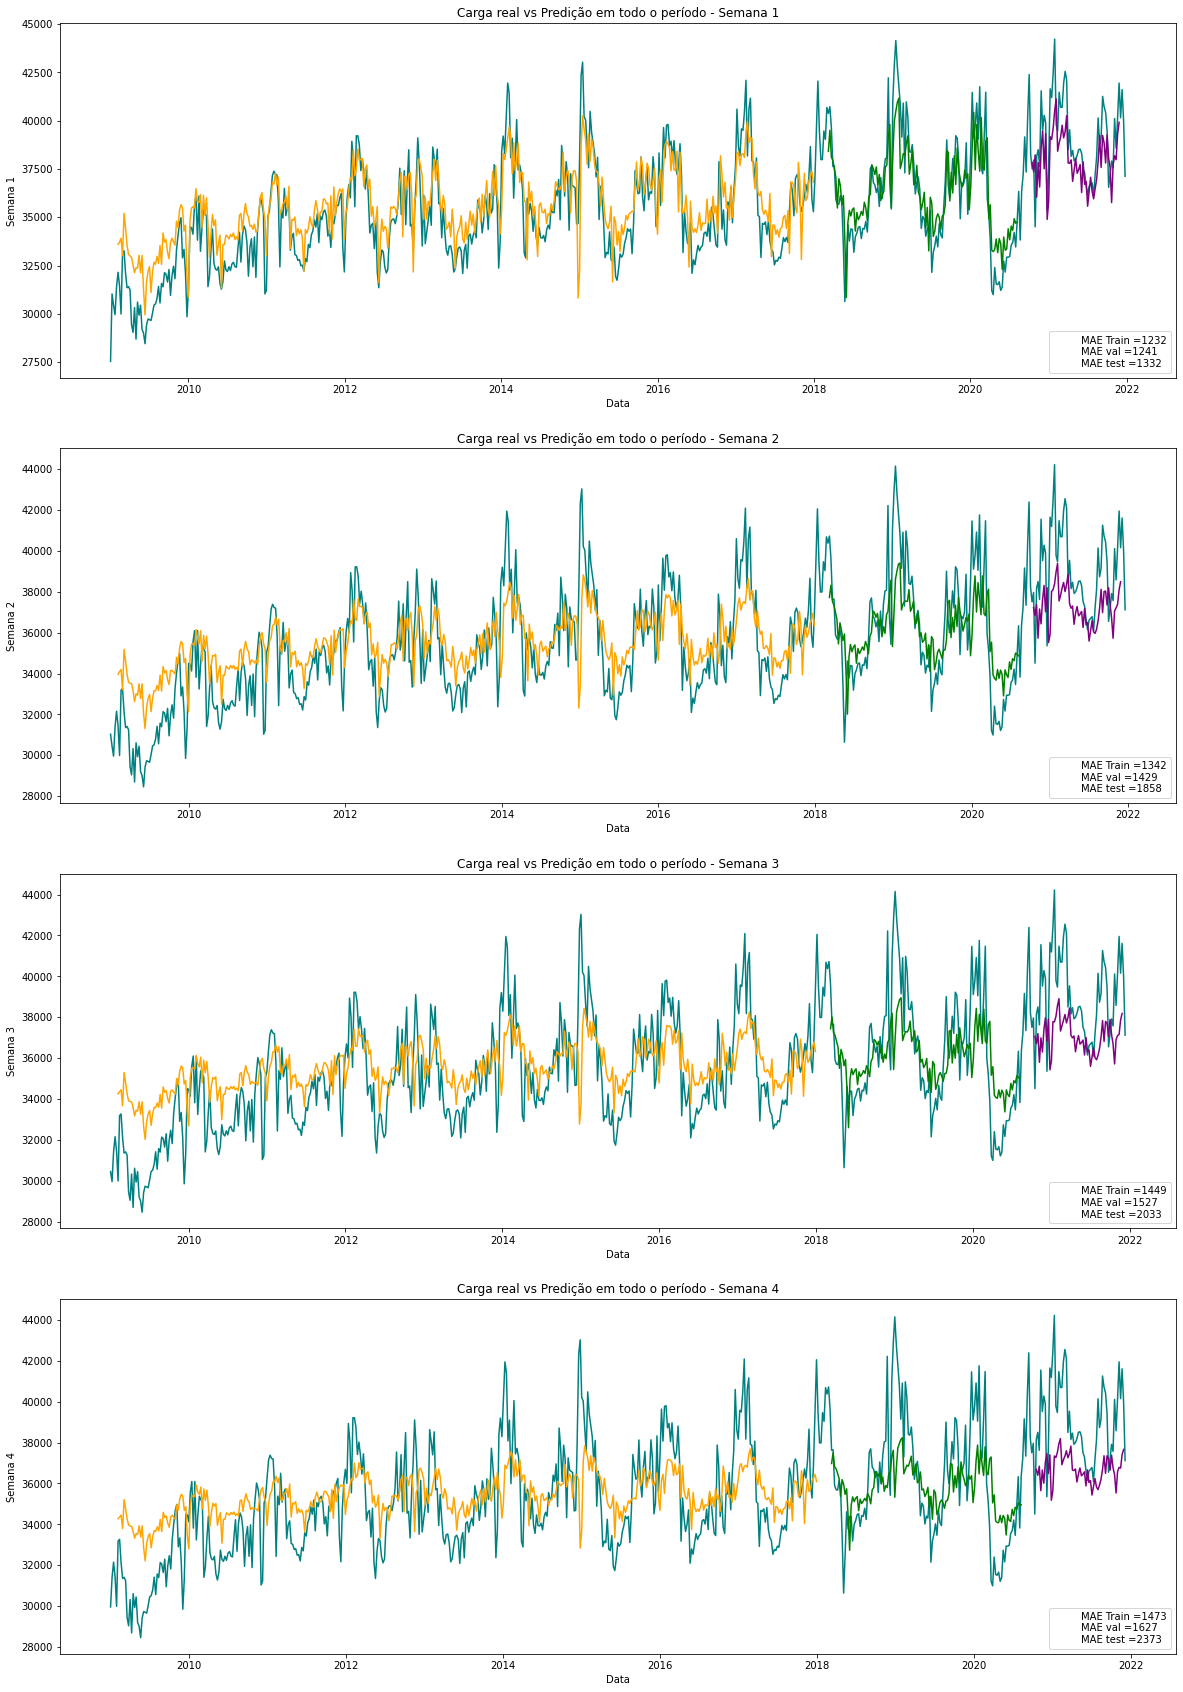

In [729]:
# load weights from the epoch with best validation loss in training
#model.load_weights(filepath)


# make predictions
train_pred = model.predict(train_pred_dataset)
val_pred = model.predict(val_dataset)
test_pred = model.predict(test_dataset)

date_list = [train_pred_data_week,val_data_week,test_data_week]
pred_list = [train_pred, val_pred, test_pred]



# evaluate performance
train_performance = {}
train_performance['LSTM'] = model.evaluate(train_dataset)
val_performance = {}
val_performance['LSTM'] = model.evaluate(val_dataset)
performance = {}
performance['LSTM'] = model.evaluate(test_dataset)

plot_pred()

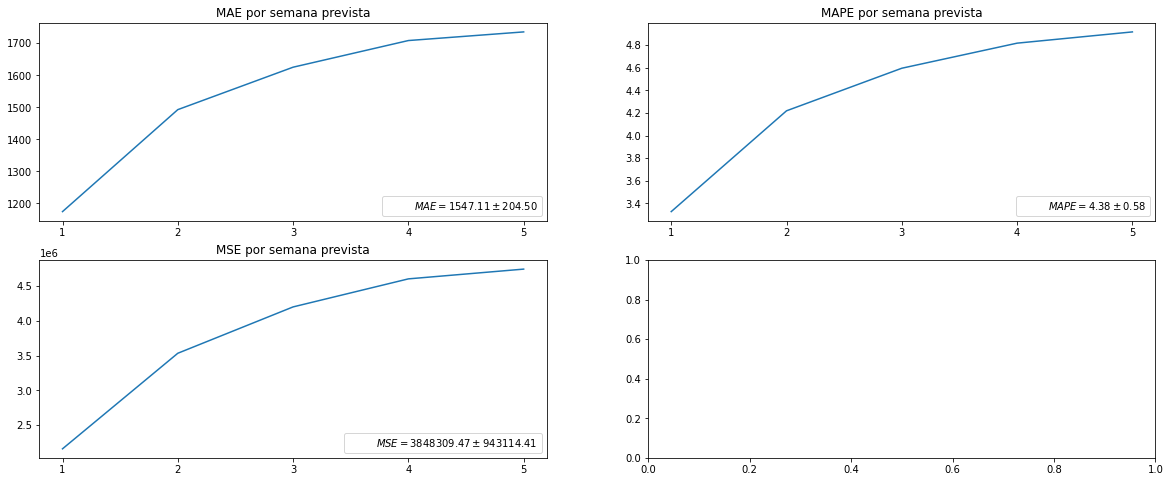

,MAE,MAPE,MSE
Semana 1,1174.573965,3.327420,2.159629e+06
Semana 2,1492.649893,4.218921,3.533826e+06
Semana 3,1625.009846,4.595421,4.200467e+06
Semana 4,1708.177553,4.817151,4.603619e+06
Semana 5,1735.128808,4.916675,4.744007e+06


In [87]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

mae_list = []
mape_list = []
mse_list = []
for i in range(0,5):
    #print(f"MAE train_pred Semana {i+1}:  {mean_absolute_error(train_pred[:,i], df_target[5 : int(len(df_target)*0.7)-4].iloc[:,i])}")
    mae_list.append(mean_absolute_error(train_pred[:,i], df_target[5 : int(len(df_target)*0.7)-4].iloc[:,i]))
for i in range(0,5):
    #print(f"MAPE train_pred Semana {i+1}: {mean_absolute_percentage_error(train_pred[:,i], df_target[5 : int(len(df_target)*0.7)-4].iloc[:,i])*100}")
    mape_list.append(mean_absolute_percentage_error(train_pred[:,i], df_target[5 : int(len(df_target)*0.7)-4].iloc[:,i])*100)
for i in range(0,5):
    #print(f"MSE train_pred Semeana {i+1}: {mean_squared_error(train_pred[:,i], df_target[5 : int(len(df_target)*0.7)-4].iloc[:,i])}")                
    mse_list.append(mean_squared_error(train_pred[:,i], df_target[5 : int(len(df_target)*0.7)-4].iloc[:,i]))


fig, ax = plt.subplots(figsize=(20,8),ncols=2,nrows=2)

# rectangle to print the metrics mean and std over it 
extra = plt.Rectangle((0, 0), 0, 0, fc="none", fill=False, ec='none', linewidth=0)
# plot MAE by week
sns.lineplot(x=range(1,6),y=mae_list, ax=ax[0,0])
ax[0,0].set_title('MAE por semana prevista')
ax[0,0].set_xticks([1,2,3,4,5])
scores = (r'$MAE={:.2f} \pm {:.2f}$').format(np.mean(mae_list),np.std(mae_list))
ax[0,0].legend([extra], [scores], loc='lower right')
# plot mape by week
sns.lineplot(x=range(1,6),y=mape_list, ax=ax[0,1])
ax[0,1].set_title('MAPE por semana prevista')
ax[0,1].set_xticks([1,2,3,4,5])
scores = (r'$MAPE={:.2f} \pm {:.2f}$').format(np.mean(mape_list),np.std(mape_list))
ax[0,1].legend([extra], [scores], loc='lower right')
# plot MSE by week
sns.lineplot(x=range(1,6),y=mse_list, ax=ax[1,0])
ax[1,0].set_title('MSE por semana prevista')
ax[1,0].set_xticks([1,2,3,4,5])
scores = (r'$MSE={:.2f} \pm {:.2f}$').format(np.mean(mse_list),np.std(mse_list))
ax[1,0].legend([extra], [scores], loc='lower right')

plt.show()

metrics_df = pd.DataFrame({'MAE': mae_list, 'MAPE':mape_list, 'MSE': mse_list})
metrics_df.index = ['Semana 1','Semana 2','Semana 3','Semana 4','Semana 5']
metrics_df

# Residual Analysis